# Iris Flower Classification














##Step 1: Import Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:

iris = load_iris()


df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


## Step 3: Exploratory Data Analysis (EDA)

In [3]:

print('Dataset Information')
print('=' * 40)
print(df.info())
print('\nStatistical Summary:')
df.describe()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:

print('Missing Values:')
print(df.isnull().sum())
print('\nNo missing values found!' if df.isnull().sum().sum() == 0 else 'Missing values detected!')

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

No missing values found!


Species Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


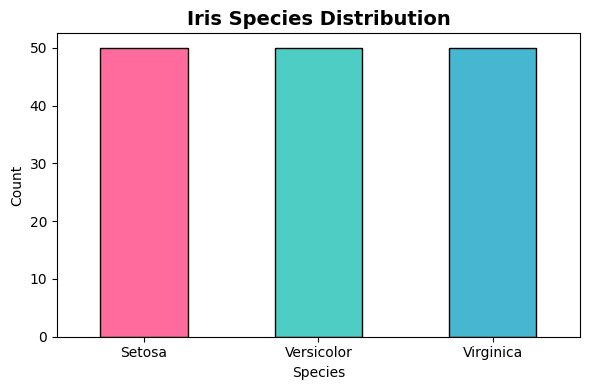

In [5]:

print('Species Distribution:')
print(df['species_name'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df['species_name'].value_counts().plot(kind='bar', color=['#FF6B9D', '#4ECDC4', '#45B7D1'], ax=ax, edgecolor='black')
ax.set_title('Iris Species Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

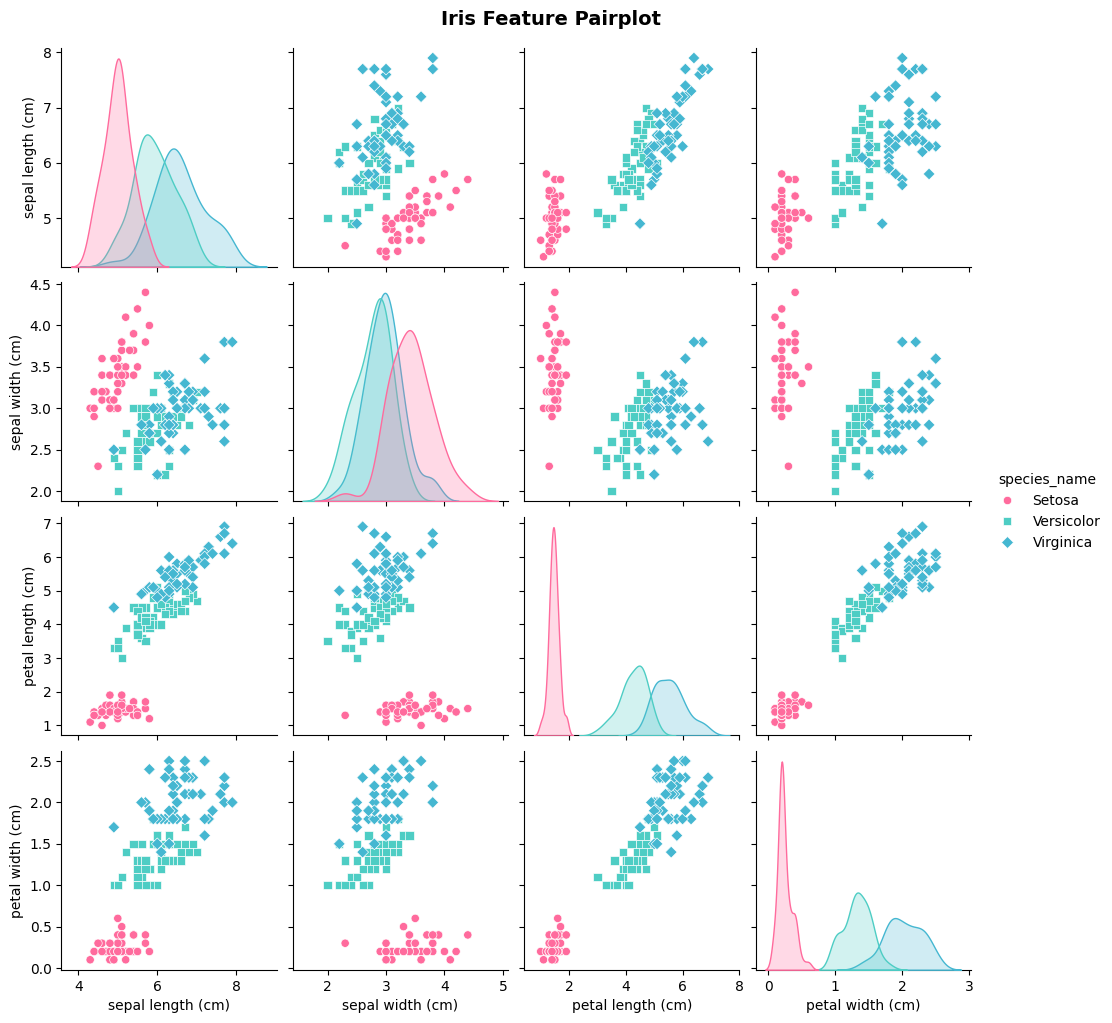

In [6]:

plt.figure(figsize=(10, 8))
sns.pairplot(df.drop('species', axis=1), hue='species_name',
             palette={'Setosa': '#FF6B9D', 'Versicolor': '#4ECDC4', 'Virginica': '#45B7D1'},
             diag_kind='kde', markers=['o', 's', 'D'])
plt.suptitle('Iris Feature Pairplot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

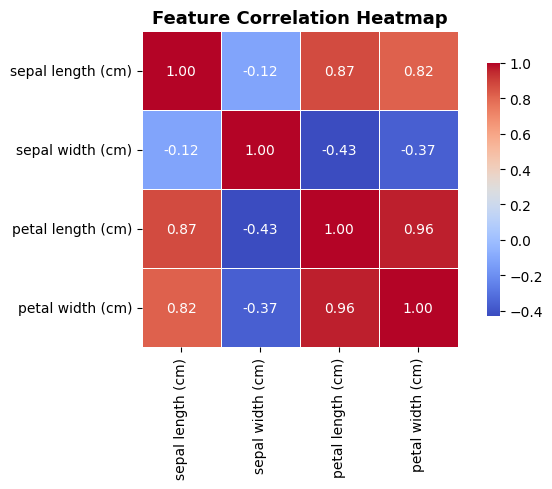

In [7]:

plt.figure(figsize=(7, 5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

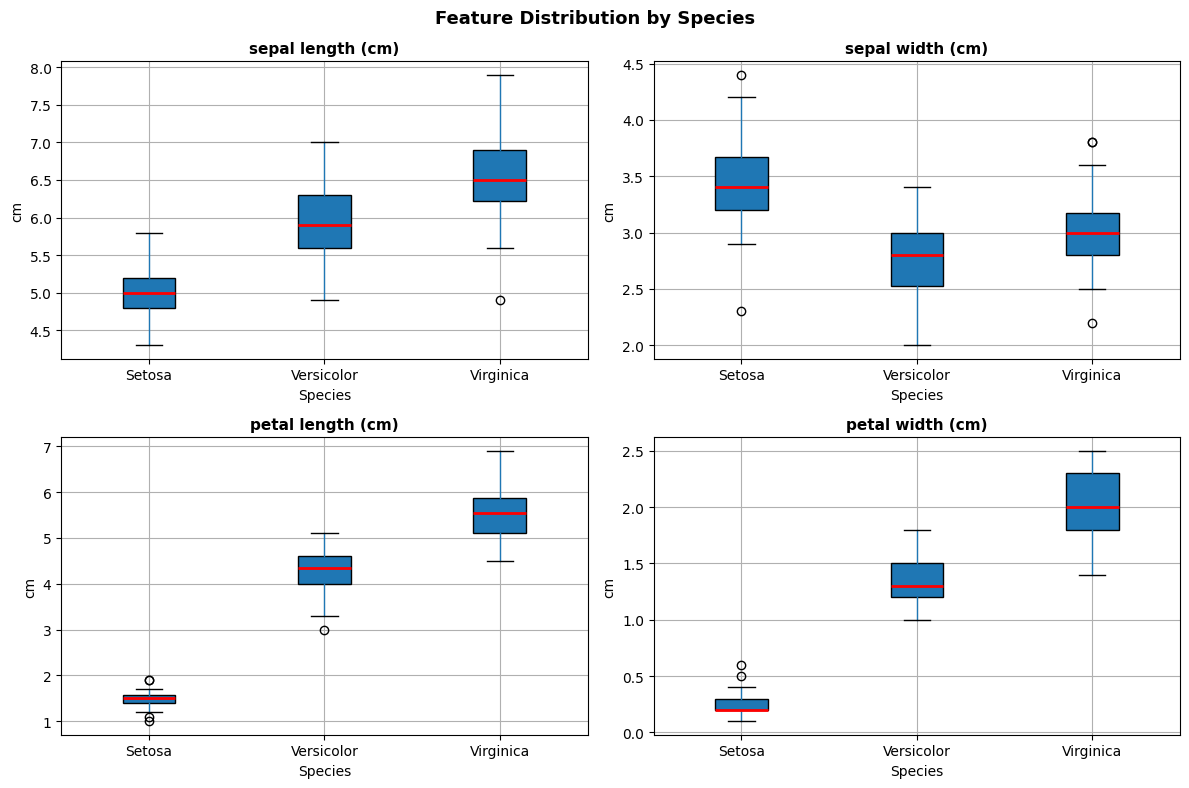

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names
colors = ['#FF6B9D', '#4ECDC4', '#45B7D1']

for i, (ax, feature) in enumerate(zip(axes.flatten(), features)):
    df.boxplot(column=feature, by='species_name', ax=ax,
               patch_artist=True,
               boxprops=dict(color='black'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel('cm')

plt.suptitle('Feature Distribution by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing & Train-Test Split

In [9]:

X = df[iris.feature_names]
y = df['species']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print('\nData split and scaled successfully!')

Training samples : 120
Testing  samples : 30

Data split and scaled successfully!


## Step 5: Train & Compare Multiple ML Models

In [10]:

models = {
    'Logistic Regression'  : LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF Kernel)'     : SVC(kernel='rbf', random_state=42),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=5)
}

results = {}

print('Model Training & Evaluation')
print('=' * 55)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = {
        'model'     : model,
        'accuracy'  : acc,
        'cv_mean'   : cv_scores.mean(),
        'cv_std'    : cv_scores.std(),
        'y_pred'    : y_pred
    }
    print(f'{name:<25} | Test Acc: {acc*100:.2f}%  | CV: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

print('=' * 55)

Model Training & Evaluation
Logistic Regression       | Test Acc: 93.33%  | CV: 95.83% ± 2.64%
Decision Tree             | Test Acc: 93.33%  | CV: 94.17% ± 2.04%
Random Forest             | Test Acc: 90.00%  | CV: 95.00% ± 1.67%
SVM (RBF Kernel)          | Test Acc: 96.67%  | CV: 96.67% ± 3.12%
K-Nearest Neighbors       | Test Acc: 93.33%  | CV: 96.67% ± 3.12%


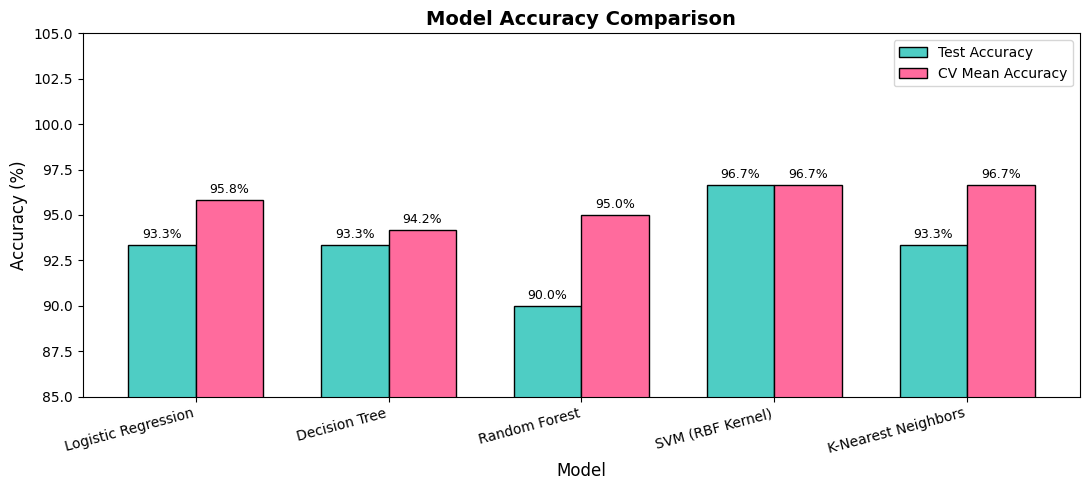

In [11]:

model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
cv_means    = [results[m]['cv_mean'] * 100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy', color='#4ECDC4', edgecolor='black')
bars2 = ax.bar(x + width/2, cv_means,   width, label='CV Mean Accuracy', color='#FF6B9D', edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(85, 105)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## Step 6: Best Model — Detailed Evaluation

In [12]:

best_name = max(results, key=lambda m: results[m]['accuracy'])
best      = results[best_name]

print(f'Best Model: {best_name}')
print(f'Test Accuracy : {best["accuracy"]*100:.2f}%')
print(f'CV Accuracy   : {best["cv_mean"]*100:.2f}% ± {best["cv_std"]*100:.2f}%')
print()


print('Classification Report:')
print(classification_report(y_test, best['y_pred'],
                            target_names=iris.target_names))

Best Model: SVM (RBF Kernel)
Test Accuracy : 96.67%
CV Accuracy   : 96.67% ± 3.12%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



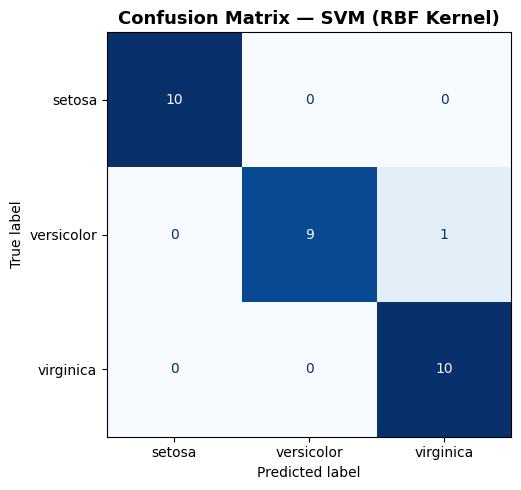

In [13]:

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:

if best_name == 'Random Forest':
    importances = best['model'].feature_importances_
    feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(feat_df['Feature'], feat_df['Importance'],
            color=['#FF6B9D', '#4ECDC4', '#45B7D1', '#FFD93D'], edgecolor='black')
    ax.set_title('🌲 Random Forest — Feature Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print(f'Feature importance chart shown only for Random Forest. Best model is {best_name}.')

Feature importance chart shown only for Random Forest. Best model is SVM (RBF Kernel).


## Step 7: Predict on New / Custom Input

In [15]:



sample_inputs = [
    [5.1, 3.5, 1.4, 0.2],
    [6.7, 3.1, 4.7, 1.5],
    [6.3, 3.3, 6.0, 2.5],
]

print('Predictions on New Flower Measurements')
print('=' * 60)
print(f'{"Sepal L":>8} {"Sepal W":>8} {"Petal L":>8} {"Petal W":>8}  →  Prediction')
print('-' * 60)

for sample in sample_inputs:
    sample_scaled = scaler.transform([sample])
    prediction    = best['model'].predict(sample_scaled)[0]
    species_name  = iris.target_names[prediction]
    emoji = '🌸' if species_name == 'setosa' else '🌺' if species_name == 'versicolor' else '🌷'
    print(f'{sample[0]:>8} {sample[1]:>8} {sample[2]:>8} {sample[3]:>8}  →  {emoji} {species_name.capitalize()}')

Predictions on New Flower Measurements
 Sepal L  Sepal W  Petal L  Petal W  →  Prediction
------------------------------------------------------------
     5.1      3.5      1.4      0.2  →  🌸 Setosa
     6.7      3.1      4.7      1.5  →  🌺 Versicolor
     6.3      3.3      6.0      2.5  →  🌷 Virginica


## Step 8: Summary & Conclusion

In [16]:
print('=' * 60)
print('IRIS FLOWER CLASSIFICATION — SUMMARY')
print('=' * 60)
print(f'  Dataset         : 150 samples × 4 features × 3 classes')
print(f'  Train/Test Split: 80% / 20%  (120 train, 30 test)')
print(f'  Scaling         : StandardScaler')
print(f'  Models Tested   : {len(models)}')
print()
print('  Model Accuracies:')
for name in results:
    marker = 'Done!' if name == best_name else '  '
    print(f'  {marker} {name:<25}: {results[name]["accuracy"]*100:.2f}%')
print()
print(f'Best Model    : {best_name}')
print(f'Test Accuracy : {best["accuracy"]*100:.2f}%')
print()
print('  Key Findings:')
print('  • Petal length and petal width are the most discriminative features')
print('  • Setosa is linearly separable from Versicolor and Virginica')
print('  • Versicolor and Virginica have some overlap, making them harder to distinguish')
print('  • All models achieved > 93% accuracy on this well-structured dataset')
print('=' * 60)

IRIS FLOWER CLASSIFICATION — SUMMARY
  Dataset         : 150 samples × 4 features × 3 classes
  Train/Test Split: 80% / 20%  (120 train, 30 test)
  Scaling         : StandardScaler
  Models Tested   : 5

  Model Accuracies:
     Logistic Regression      : 93.33%
     Decision Tree            : 93.33%
     Random Forest            : 90.00%
  Done! SVM (RBF Kernel)         : 96.67%
     K-Nearest Neighbors      : 93.33%

Best Model    : SVM (RBF Kernel)
Test Accuracy : 96.67%

  Key Findings:
  • Petal length and petal width are the most discriminative features
  • Setosa is linearly separable from Versicolor and Virginica
  • Versicolor and Virginica have some overlap, making them harder to distinguish
  • All models achieved > 93% accuracy on this well-structured dataset
